In [616]:
#Question 4

'''
In the 'spike_trains' folder, you will find a file called 'stim.dat'. 
This file contains the motion stimulus that triggered the spike train recorded in 'rho.dat'. 
Calculate the spike-triggered average (STA) over a 100 ms time window and plot the result.
'''

'''
# Code for Spike Triggered Average (STA) calculation
# Compare STA for real spike train data and LIF neuron
# Stimulus-triggered by pairs of spikes and analysis of refractory effects
'''

import numpy as np
import matplotlib.pyplot as plt
import math

#read rho.dat into an array
spike_train = np.loadtxt('rho.dat')
#spike_train = np.random.choice([0, 1], 1000)
print(spike_train)
#Parameters

#read stim.dat into an array
stimulus = np.loadtxt('stim.dat')
#stimulus = np.random.randint(-150, 151, size=1000)
print(stimulus)



time_window = 0.1 #[s]
total_time = 1200 #[s]
sampling_rate = 0.002 #[s] 1 sample every 0.002s



[0. 0. 0. ... 0. 0. 0.]
[-111.94824219  -81.80664062   10.21972656 ...    9.78515625   24.11132812
   50.25390625]


In [617]:
'''
To calculate the spike-triggered average (STA), you need to align the stimulus data with the spike train. For each spike in rho.dat, you will:

Take a 100 ms window of stimulus data from stim.dat around the time of the spike.
Average the stimulus values across all spikes.

This gives you the STA, which shows how the stimulus typically looks around the time of the spikes.
'''

#Import data from stim.dat in windows of 100ms 
#windows of 100ms centered around spikes in rho.dat (50 to the right and 50 to the left of the spike in rho.dat)
# 100MS - split spike array into chunks of 50 samples (100 ms / 2 ms = 50 samples)

#num of samples per 100ms window (int to avoid slicing errors)
nSamples_100ms = int(time_window / sampling_rate)

#center windows around spikes
spike_idx = np.array(np.where(spike_train)[0]) #returns array of spike indices

#average stimulation around spike in 100ms windows list
window_avgs = []
#train_window_100ms = []
start_idx = []

#calculate start & end of 100ms time window
for i in spike_idx:
    #removing fractions after division by 2
    start = max(0, i - nSamples_100ms //2) #ensures i isnt below 0
    end = min(len(stimulus), i + nSamples_100ms //2) #ensures i isnt above len(spike_train)

    #slicing spike train to spike-centered 100ms windows & appending to window list
    stim_window_100ms = stimulus[start:end]
    #train_window_100ms.append(spike_train[start:end])

    #print(f"Window {start}:{end}:", stim_window_100ms)

    avg_window = np.mean(stim_window_100ms)
    #print(f"Average of this window: {avg_window}")

    window_avgs.append(avg_window)

window_avgs = np.array(window_avgs)

print("Window averages:", window_avgs)

#average across all spikes
sta = np.mean(window_avgs)

print("STA (average across all spikes):", sta)


Window averages: [25.38632347 24.23454122 19.35488281 ... -3.19335938  5.38212891
 -3.56464844]
STA (average across all spikes): 7.276198346736966


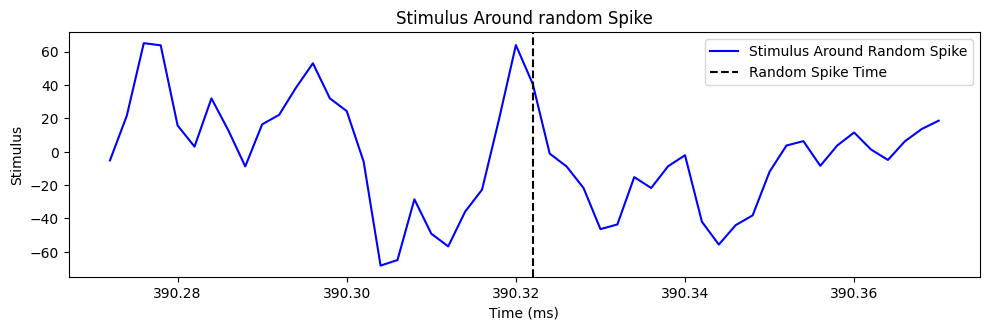

In [623]:
#select random spike index that has at least 50ms before and after
valid_spikes = spike_idx[(spike_idx > nSamples_100ms // 2) & (spike_idx < len(spike_train) - nSamples_100ms // 2)]
random_spike_idx = np.random.choice(valid_spikes)  #rand spike

#calcu start and end of 100ms window around random spike
start_idx = random_spike_idx - nSamples_100ms // 2
end_idx = random_spike_idx + nSamples_100ms // 2

#100ms window time vector
stim_time_window = np.arange(start_idx, end_idx) * sampling_rate

#extract stimulus around spike
stim_window_100ms = stimulus[start_idx:end_idx]

#plot spike train stimulus around randomly selected spike
plt.figure(figsize=(10, 6))

#plot stimulus around random spike
plt.subplot(2, 1, 2)
plt.plot(stim_time_window, stim_window_100ms, label="Stimulus Around Random Spike", color="blue")
plt.axvline(x=random_spike_idx * sampling_rate, color='black', linestyle='--', label="Random Spike Time")
plt.xlabel("Time (ms)")
plt.ylabel("Stimulus")
plt.title("Stimulus Around random Spike")
plt.tight_layout()
plt.legend()
plt.show()


In [ ]:
#assuming 'stimulus' contains both excitatory and inhibitory components
#we'll treat positive values as excitatory and negative as inhibitory

def separate_excitatory_inhibitory(stimulus):
    excitatory = stimulus[stimulus > 0]  #positive stimulus as excitatory
    inhibitory = stimulus[stimulus < 0]  #negative stimulus as inhibitory
    return excitatory, inhibitory

#separate excitatory and inhibitory components of stimulus
exc_stimulus, inh_stimulus = separate_excitatory_inhibitory(stimulus)

#calculate STA for excitatory and inhibitory stimuli separately
sta_exc = sta(exc_stimulus, spikes, window_size) #what window avrgs?
sta_inh = sta(inh_stimulus, spikes, window_size)

# Plot both
plt.subplot(1, 2, 1)
plt.plot(sta_exc)
plt.title("STA for Excitatory Stimulus")
plt.xlabel("Time (ms)")
plt.ylabel("STA Value")

plt.subplot(1, 2, 2)
plt.plot(sta_inh)
plt.title("STA for Inhibitory Stimulus")
plt.xlabel("Time (ms)")
plt.ylabel("STA Value")

plt.tight_layout()
plt.show()


NameError: name 'spikes' is not defined